In [1]:
import sys
print(sys.executable)

c:\Users\Aviral Maheshwari\OneDrive\Desktop\vs code avi\venv\Scripts\python.exe


In [2]:
import sys

!"{sys.executable}" -m pip install pandas numpy matplotlib seaborn openpyxl

CUSTOMER SALES ANALYSIS PROJECT

Loading datasets...
Datasets loaded successfully.

Sales Dataset
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  01-01-2024       Phone         7  37300     CUST001   East       261100
1  02-01-2024  Headphones         4  15406     CUST002  North        61624
2  03-01-2024       Phone         2  21746     CUST003   West        43492
3  04-01-2024  Headphones         1  30895     CUST004   East        30895
4  05-01-2024      Laptop         8  39835     CUST005  North       318680

Sales Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  10

C:\Users\Aviral Maheshwari\AppData\Local\Temp\ipykernel_16772\2479405669.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


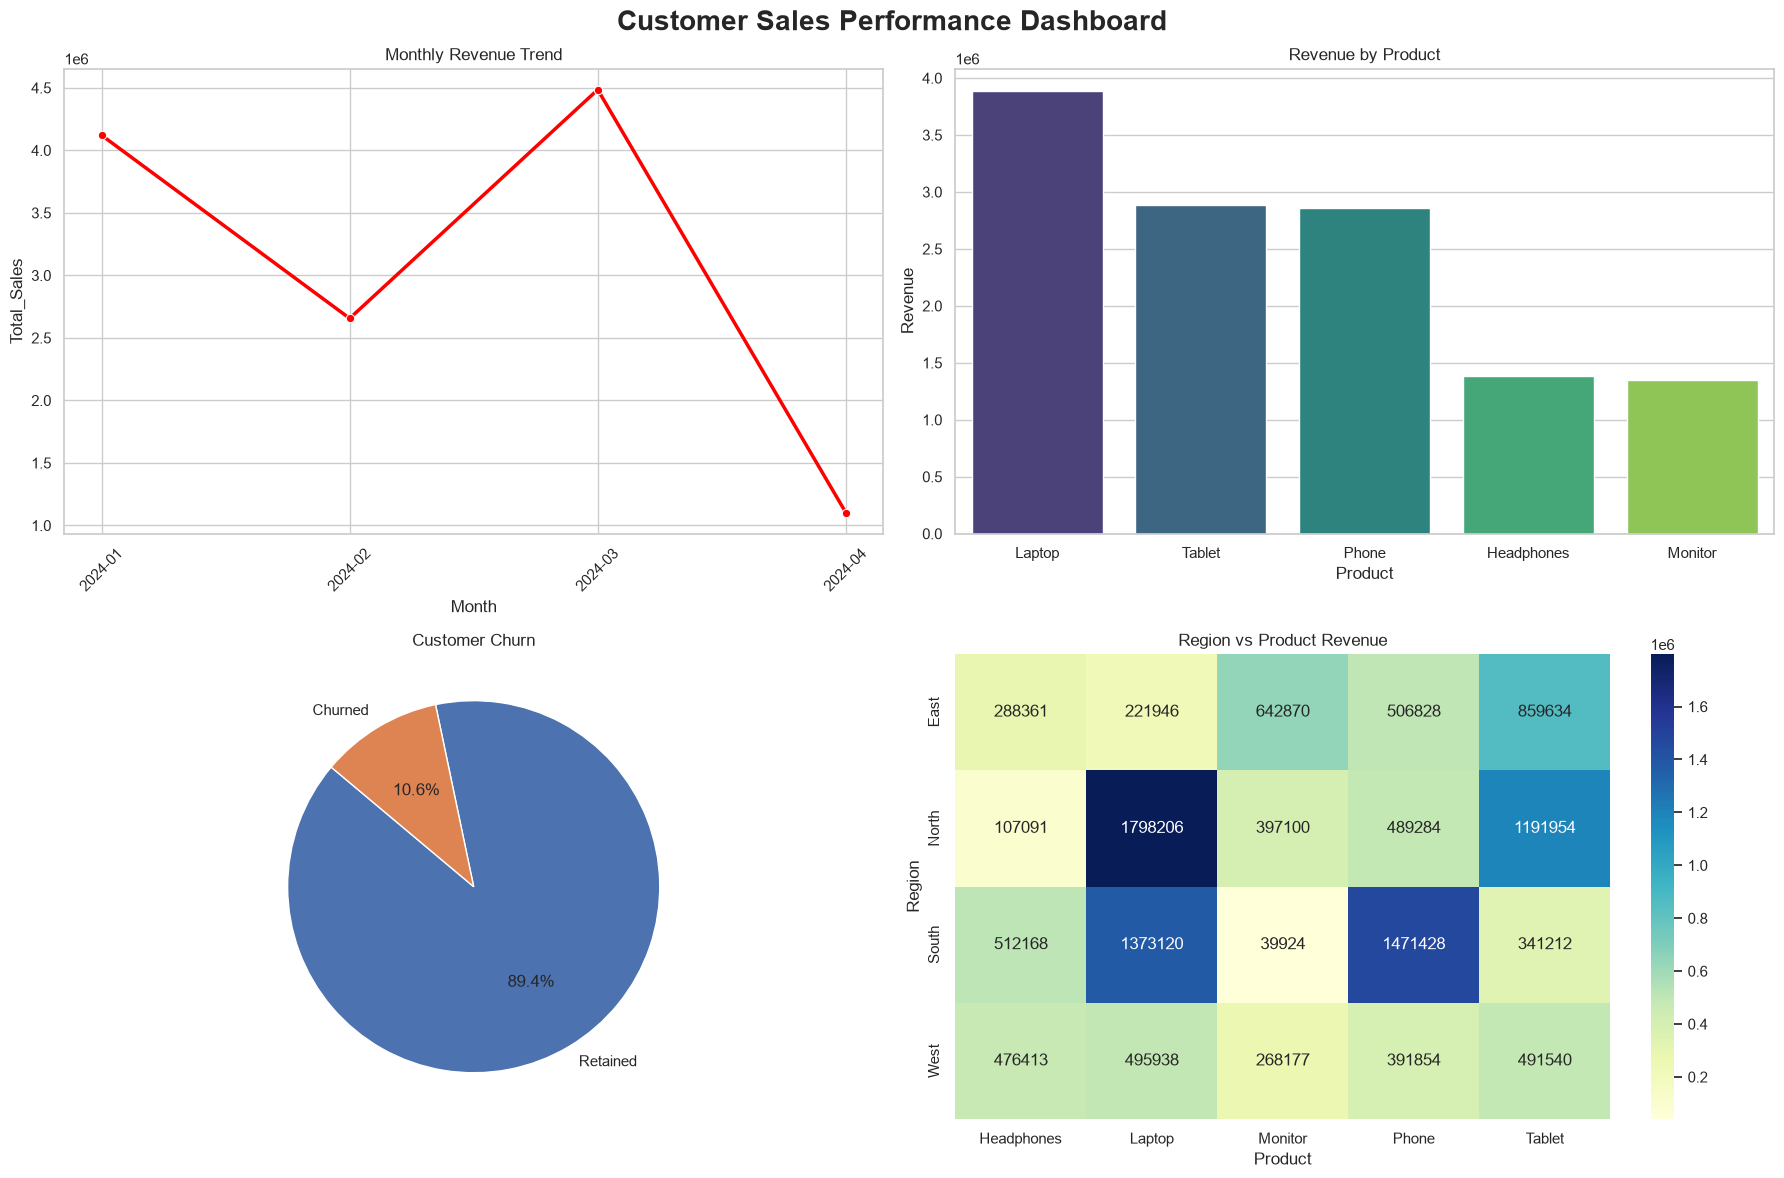

C:\Users\Aviral Maheshwari\AppData\Local\Temp\ipykernel_16772\2479405669.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


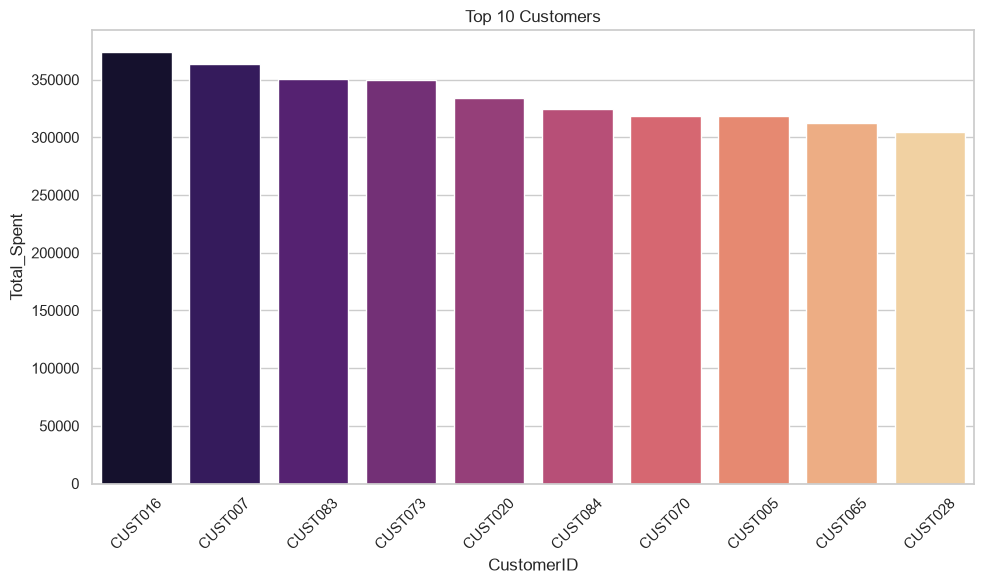

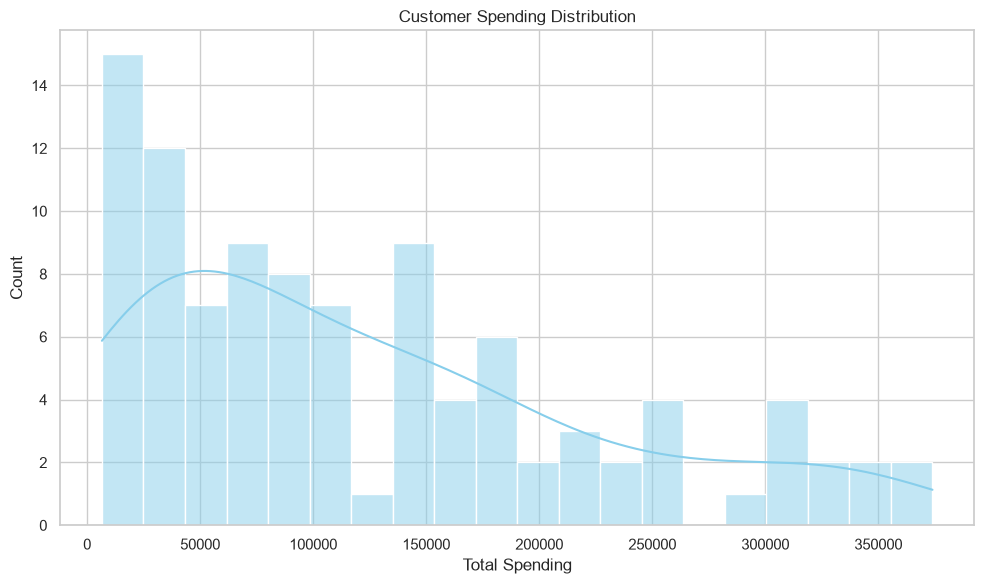



FINAL SALES ANALYSIS REPORT
Total Revenue              : $12,365,048.00
Total Customers            : 100
Average Order Value        : $123,650.48
Top Customer               : CUST016
Top Customer Spending      : $373,932.00
Customer Retention Rate    : 89.40%

Project Completed Successfully.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CUSTOMER SALES ANALYSIS PROJECT
# ============================================================

# Professional Plot Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("=" * 60)
print("CUSTOMER SALES ANALYSIS PROJECT")
print("=" * 60)

# ============================================================
# DAY 1 : LOAD DATA
# ============================================================

print("\nLoading datasets...")

sales_df = pd.read_csv("sales_data (2).csv")
churn_df = pd.read_csv("customer_churn.csv")

print("Datasets loaded successfully.")

# ============================================================
# DAY 1 : DATA EXPLORATION
# ============================================================

print("\nSales Dataset")
print(sales_df.head())

print("\nSales Dataset Info")
print(sales_df.info())

print("\nSales Dataset Statistics")
print(sales_df.describe())

print("\nMissing Values in Sales Data")
print(sales_df.isnull().sum())

print("\nCustomer Churn Dataset")
print(churn_df.head())

print("\nCustomer Churn Info")
print(churn_df.info())

print("\nCustomer Churn Statistics")
print(churn_df.describe(include="all"))

print("\nMissing Values in Churn Data")
print(churn_df.isnull().sum())

# ============================================================
# DAY 2 : DATA CLEANING
# ============================================================

print("\nCleaning Data...")

sales_df.rename(columns={"Customer_ID": "CustomerID"}, inplace=True)

sales_df["Date"] = pd.to_datetime(
    sales_df["Date"],
    dayfirst=True,
    errors="coerce"
)

sales_df.dropna(inplace=True)
churn_df.dropna(inplace=True)

print("Cleaning Completed.")

# ============================================================
# DAY 3 : DATA MERGING
# ============================================================

merged_df = pd.merge(
    sales_df,
    churn_df,
    on="CustomerID",
    how="left"
)

print("\nMerged Dataset Shape:", merged_df.shape)

# ============================================================
# DAY 4 : AGGREGATIONS
# ============================================================

print("\nRunning Aggregations...")

# Customer Sales
customer_sales = sales_df.groupby("CustomerID").agg(
    Total_Spent=("Total_Sales", "sum"),
    Order_Count=("Total_Sales", "count"),
    Average_Order_Value=("Total_Sales", "mean")
).reset_index()

top_customers = customer_sales.sort_values(
    by="Total_Spent",
    ascending=False
)

print("\nTop 10 Customers")
print(top_customers.head(10))

# Monthly Revenue
sales_df["Month"] = sales_df["Date"].dt.to_period("M")

monthly_sales = sales_df.groupby("Month")["Total_Sales"].sum().reset_index()

# Product Performance
product_sales = sales_df.groupby("Product").agg(
    Revenue=("Total_Sales", "sum"),
    Units_Sold=("Quantity", "sum")
).reset_index()

product_sales = product_sales.sort_values(
    by="Revenue",
    ascending=False
)

# Region Performance
region_sales = sales_df.groupby("Region").agg(
    Revenue=("Total_Sales", "sum"),
    Orders=("CustomerID", "count")
).reset_index()

print("\nRegion Performance")
print(region_sales)

# ============================================================
# DAY 5 : PIVOT TABLE
# ============================================================

pivot_table = pd.pivot_table(
    sales_df,
    values="Total_Sales",
    index="Region",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

print("\nPivot Table")
print(pivot_table)

# ============================================================
# EXPORT RESULTS
# ============================================================

customer_sales.to_csv("customer_sales_summary.csv", index=False)
monthly_sales.to_csv("monthly_sales_summary.csv", index=False)
product_sales.to_csv("product_sales_summary.csv", index=False)
region_sales.to_csv("region_sales_summary.csv", index=False)
pivot_table.to_csv("region_product_pivot.csv")

print("\nSummary CSV files exported successfully.")

# ============================================================
# DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Customer Sales Performance Dashboard",
    fontsize=20,
    fontweight="bold"
)

# Monthly Revenue
sns.lineplot(
    ax=axes[0, 0],
    data=monthly_sales.astype({"Month": str}),
    x="Month",
    y="Total_Sales",
    marker="o",
    linewidth=2.5,
    color="red"
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].tick_params(axis="x", rotation=45)

# Product Revenue
sns.barplot(
    ax=axes[0, 1],
    data=product_sales,
    x="Product",
    y="Revenue",
    palette="viridis"
)

axes[0, 1].set_title("Revenue by Product")

# Churn Distribution
churn_counts = churn_df["Churn"].value_counts()

axes[1, 0].pie(
    churn_counts,
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    startangle=140
)

axes[1, 0].set_title("Customer Churn")

# Heatmap
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Region vs Product Revenue")

plt.tight_layout()

plt.savefig("customer_sales_dashboard.png", dpi=300)

plt.show()

# ============================================================
# EXTRA VISUALIZATION 1
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers.head(10),
    x="CustomerID",
    y="Total_Spent",
    palette="magma"
)

plt.title("Top 10 Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("top_10_customers.png", dpi=300)

plt.show()

# ============================================================
# EXTRA VISUALIZATION 2
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    customer_sales["Total_Spent"],
    bins=20,
    kde=True,
    color="skyblue"
)

plt.title("Customer Spending Distribution")

plt.xlabel("Total Spending")

plt.tight_layout()

plt.savefig("customer_spending_distribution.png", dpi=300)

plt.show()

# ============================================================
# FINAL REPORT
# ============================================================

total_revenue = sales_df["Total_Sales"].sum()

total_customers = sales_df["CustomerID"].nunique()

average_order = sales_df["Total_Sales"].mean()

top_customer = top_customers.iloc[0]["CustomerID"]

top_customer_sales = top_customers.iloc[0]["Total_Spent"]

retention_rate = (1 - churn_df["Churn"].mean()) * 100

print("\n")
print("=" * 60)
print("FINAL SALES ANALYSIS REPORT")
print("=" * 60)

print(f"Total Revenue              : ${total_revenue:,.2f}")
print(f"Total Customers            : {total_customers}")
print(f"Average Order Value        : ${average_order:,.2f}")
print(f"Top Customer               : {top_customer}")
print(f"Top Customer Spending      : ${top_customer_sales:,.2f}")
print(f"Customer Retention Rate    : {retention_rate:.2f}%")

print("=" * 60)

print("\nProject Completed Successfully.")